In [3]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from statannotations.Annotator import Annotator

from scipy.stats import mannwhitneyu, shapiro
from statsmodels.stats.multitest import multipletests

from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

from skbio.stats.composition import clr, multi_replace
from skbio.stats.distance import permanova, DistanceMatrix
from scipy.spatial.distance import braycurtis, pdist, squareform

import autoimmune_analysis.TCR_utils as utils

import os
from itertools import combinations

In [4]:
metadata_path = "../data/metadata_ifn_predictions.csv"
results_path = "../../../results/results_mixcr"

metadata = pd.read_csv(metadata_path)

# V, D and J segment gene usage of TCR beta chain

This notebook presents the results of TCR repertoire analysis we managed to achieve for beta chain of T-cell receptors. For all genes count matrices were obtained and transformed to frequency matrices. After that frequency distributions and medians were compared between sample groups using perMANOVA and pairwise Mann-Whitney criterion. Central log transformation was used in order to account for compositional natural of frequency data.

For V-segment genes we managed to achieve the reduction of batch-effect after generating frequency matrices. This implies that frequencies can be used for analysing V, D and J-segment gene usage across different datasets.

## V-segment gene usage analysis

First of all, we generated a TRBV-gene count matrix from the data that was output by MiXCR tool.

In [5]:
v_count_matrix = utils.get_gene_count_matrix(
    gene = "TRB",
    segment = "V",
    results_dir = results_path,
    metadata = metadata
).T

v_gene_cols = v_count_matrix.columns
v_count_matrix.head()

gene,TRBV1,TRBV10-1,TRBV10-2,TRBV10-3,TRBV11-1,TRBV11-2,TRBV11-3,TRBV12-1,TRBV12-2,TRBV12-3,...,TRBV7-1,TRBV7-2,TRBV7-3,TRBV7-4,TRBV7-5,TRBV7-6,TRBV7-7,TRBV7-8,TRBV7-9,TRBV9
srr,,,,,,,,,,,,,,,,,,,,,
SRR10342368,0.0,0.0,2.0,4.0,4.0,9.0,1.0,0.0,0.0,19.0,...,0.0,7.0,3.0,0.0,0.0,3.0,1.0,3.0,6.0,3.0
SRR10342369,0.0,26.0,15.0,30.0,7.0,39.0,20.0,1.0,0.0,142.0,...,1.0,71.0,26.0,0.0,0.0,11.0,1.0,57.0,100.0,140.0
SRR10342370,1.0,2.0,8.0,44.0,19.0,43.0,8.0,0.0,0.0,98.0,...,0.0,95.0,29.0,3.0,0.0,13.0,5.0,16.0,90.0,46.0
SRR10342371,1.0,0.0,20.0,28.0,15.0,25.0,9.0,1.0,1.0,57.0,...,2.0,112.0,16.0,3.0,0.0,12.0,7.0,30.0,71.0,28.0
SRR12794681,0.0,2.0,4.0,7.0,4.0,21.0,1.0,0.0,0.0,28.0,...,0.0,16.0,7.0,0.0,0.0,10.0,11.0,1.0,41.0,10.0


### PCA for batch-effect visualisation

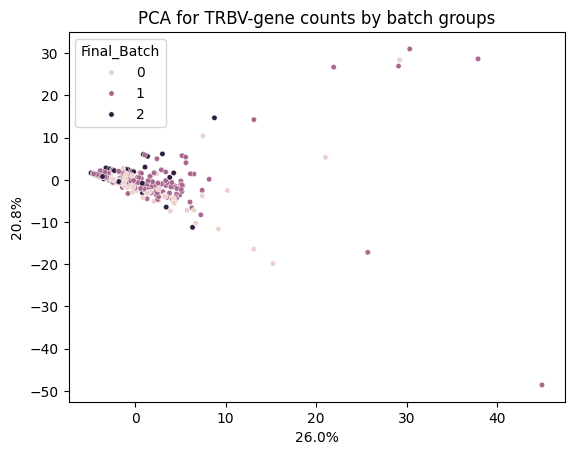

In [6]:
SRRs = v_count_matrix.index

scaler = RobustScaler()
scaled_cm = pd.DataFrame(scaler.fit_transform(v_count_matrix))

pca_obj = PCA(n_components=62)
principal_comps = pd.DataFrame(
    pca_obj.fit_transform(scaled_cm),
    columns = [f"PC{i+1}" for i in range(scaled_cm.shape[1]-1)]
)
principal_comps["SRR"] = SRRs

meta_subset = metadata[["SRR", "diagnosis", "Final_Batch", "predicted_ifn_status", "GSE"]]

principal_comps = principal_comps.merge(meta_subset, on="SRR", how = "inner")

sns.scatterplot(data=principal_comps,
                    x="PC1",
                    y="PC2",
                    hue="Final_Batch",
                    s=15)
plt.xlabel(f'{pca_obj.explained_variance_ratio_[0] * 100:.1f}%')
plt.ylabel(f'{pca_obj.explained_variance_ratio_[1] * 100:.1f}%')

plt.title("PCA for TRBV-gene counts by batch groups")
plt.show()

It is clear that some samples clusterize based on the assigned batch group. In order to account for that we calculated gene frequencies and applied CLR-transformation and worked with such data for the subsequent analysis.

#### Calculating frequencies and CLR-transformation

In [7]:
v_freq_matrix = v_count_matrix[v_gene_cols].div(
    v_count_matrix[v_gene_cols].sum(axis = 1), axis = 0
)

clr_V_freqs = utils.clr_transform(v_freq_matrix)


#### PCA on CLR-transformed frequencies

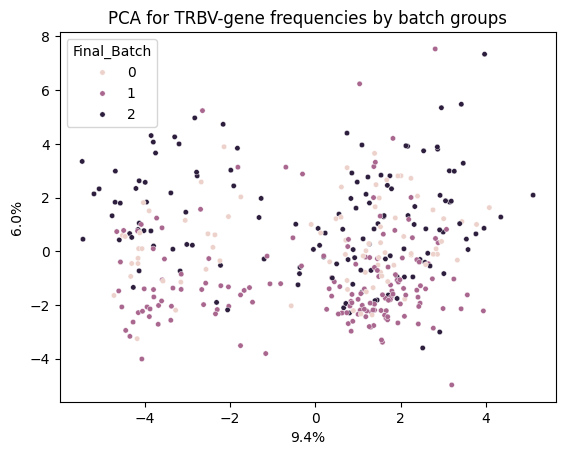

In [8]:
pca_obj = PCA(n_components=62)
principal_comps = pd.DataFrame(
    pca_obj.fit_transform(clr_V_freqs),
    columns = [f"PC{i+1}" for i in range(62)]
)
principal_comps["SRR"] = SRRs

principal_comps = principal_comps.merge(meta_subset, on="SRR", how = "inner")

sns.scatterplot(data=principal_comps,
                    x="PC1",
                    y="PC2",
                    hue="Final_Batch",
                    s=15)
plt.xlabel(f'{pca_obj.explained_variance_ratio_[0] * 100:.1f}%')
plt.ylabel(f'{pca_obj.explained_variance_ratio_[1] * 100:.1f}%')

plt.title("PCA for TRBV-gene frequencies by batch groups")
plt.show()

There is still some visible effect of batch groups on the resulting values, but data distribution demonstrates better uniformity. 

### TRBV-gene usage profiles

For the primary comparison of beta-chain V-gene usage profiles between High and Low interferon response groups across 4 diagnosis groups we used perMANOVA. If any significant difference had been found, pairwise Mann-Whitney criterion was used in order to identify genes responsible for it.

#### perMANOVA

In [9]:
clr_V_df = clr_V_freqs.reset_index().merge(meta_subset, left_on = "srr", right_on = "SRR", how = "inner")

for diagnosis in clr_V_df["diagnosis"].unique():
    subset = clr_V_df[clr_V_df["diagnosis"] == diagnosis]

    if subset["predicted_ifn_status"].nunique() < 2:
        print(f"\n=== {diagnosis}: только одна группа интерферона, пропускаем ===")
        continue
    
    dist_sub = squareform(pdist(subset[v_gene_cols], metric="euclidean"))
    dm_sub = DistanceMatrix(dist_sub, ids=subset.index)
    
    result = permanova(dm_sub, subset["predicted_ifn_status"].astype(str), permutations=999)
    print(f"\n=== diagnosis: {diagnosis} ===")
    print(result)


=== diagnosis: SLE ===
method name               PERMANOVA
test statistic name        pseudo-F
sample size                     193
number of groups                  2
test statistic             1.997672
p-value                       0.005
number of permutations          999
Name: PERMANOVA results, dtype: object

=== diagnosis: H ===
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      59
number of groups                  2
test statistic             1.348868
p-value                        0.14
number of permutations          999
Name: PERMANOVA results, dtype: object

=== diagnosis: MS ===
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      63
number of groups                  2
test statistic             0.730992
p-value                       0.849
number of permutations          999
Name: PERMANOVA results, dtype: object

=== diagnosis: CLE ===
method name               PERMANOV

Some statistical significance was found for High and Low interferon response group with SLE. However, other diagnosis group did not show any significant difference in TRBV usage profiles between Low and High interferon samples. Considering this, genes that are possibly responsible for anti-interferon beta immune response were identified using pairwise Mann-Whitney criterion.

Mann-Whitney pairwise comparison results are presented below:

In [10]:
all_results = []

subset = clr_V_df[clr_V_df["diagnosis"] == "SLE"]

g1 = subset[subset["predicted_ifn_status"] == "High"]
g2 = subset[subset["predicted_ifn_status"] == "Low"]

for gene in v_gene_cols:
    stat, p = mannwhitneyu(g1[gene].values, g2[gene].values, alternative="two-sided")
    all_results.append({
        "diagnosis": "SLE",
        "gene": gene,
        "p_value": p,
        "mean_g1": g1[gene].mean(),
        "mean_g2": g2[gene].mean(),
        "group1": "High",
        "group2": "Low",
    })

results_df = pd.DataFrame(all_results)

results_df["p_adj"] = results_df.groupby("diagnosis")["p_value"].transform(
    lambda p: multipletests(p, method="fdr_bh")[1]
)

sig = results_df[results_df["p_adj"] < 0.05].sort_values(["diagnosis", "p_adj"])
display(sig)

,diagnosis,gene,p_value,mean_g1,mean_g2,group1,group2,p_adj
47,SLE,TRBV6-4,0.000099,-0.756895,-0.191024,High,Low,0.006238
23,SLE,TRBV23-1,0.000237,-1.292771,-0.647200,High,Low,0.007453
29,SLE,TRBV29-1,0.001845,2.457543,2.728866,High,Low,0.038744


High vs. Low: Mann-Whitney-Wilcoxon test two-sided, P_val:2.816e-04 U_stat=3.242e+03
High vs. Low: Mann-Whitney-Wilcoxon test two-sided, P_val:6.805e-04 U_stat=3.334e+03


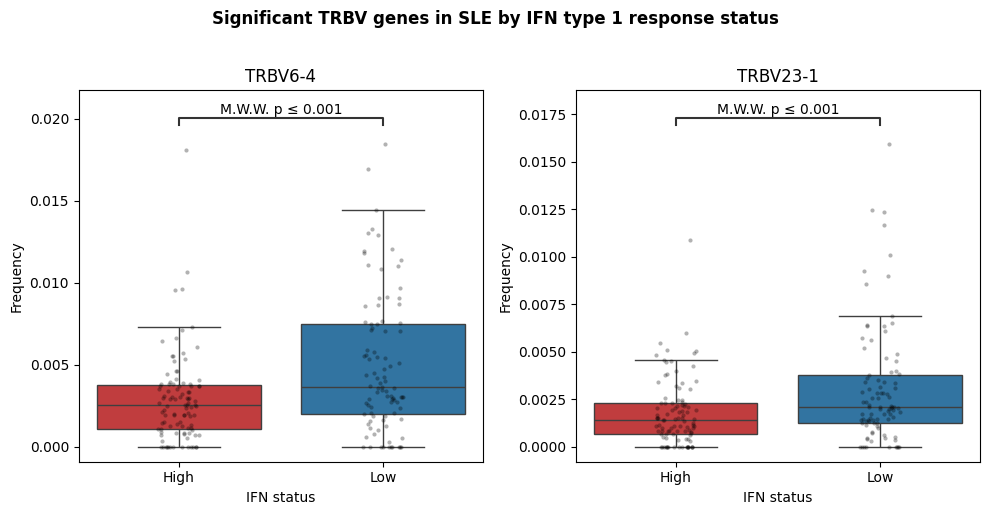

In [11]:
sig_genes = ["TRBV6-4", "TRBV23-1"]

v_freq_matrix = v_freq_matrix.reset_index().merge(meta_subset, left_on="srr", right_on="SRR", how="inner")
sle = v_freq_matrix[v_freq_matrix["diagnosis"] == "SLE"].copy()

fig, axes = plt.subplots(1, len(sig_genes), figsize=(5 * len(sig_genes), 5))

pairs = [("High", "Low")]

for ax, gene in zip(axes, sig_genes):
    sns.boxplot(data=sle,
                x="predicted_ifn_status",
                y=gene,
                ax=ax,
                order=["High", "Low"],
                hue="predicted_ifn_status",
                palette={'High': '#d62728', 'Low': '#1f77b4'},
                legend=False,
                showfliers=False)
    sns.stripplot(data=sle, x="predicted_ifn_status", y=gene, ax=ax, order=["High", "Low"],
                  color="black", alpha=0.3, size=3)

    annotator = Annotator(ax, pairs, data=sle, x="predicted_ifn_status", y=gene, order=["High", "Low"])
    annotator.configure(test="Mann-Whitney", text_format="simple", loc="inside")
    annotator.apply_and_annotate()

    ax.set_title(gene)
    ax.set_xlabel("IFN status")
    ax.set_ylabel("Frequency")

plt.suptitle("Significant TRBV genes in SLE by IFN type 1 response status", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Final visualisation of TRBV usage profiles across samples

/home/bioinf2026/losev1/miniforge3/envs/MiXCR_analysis/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


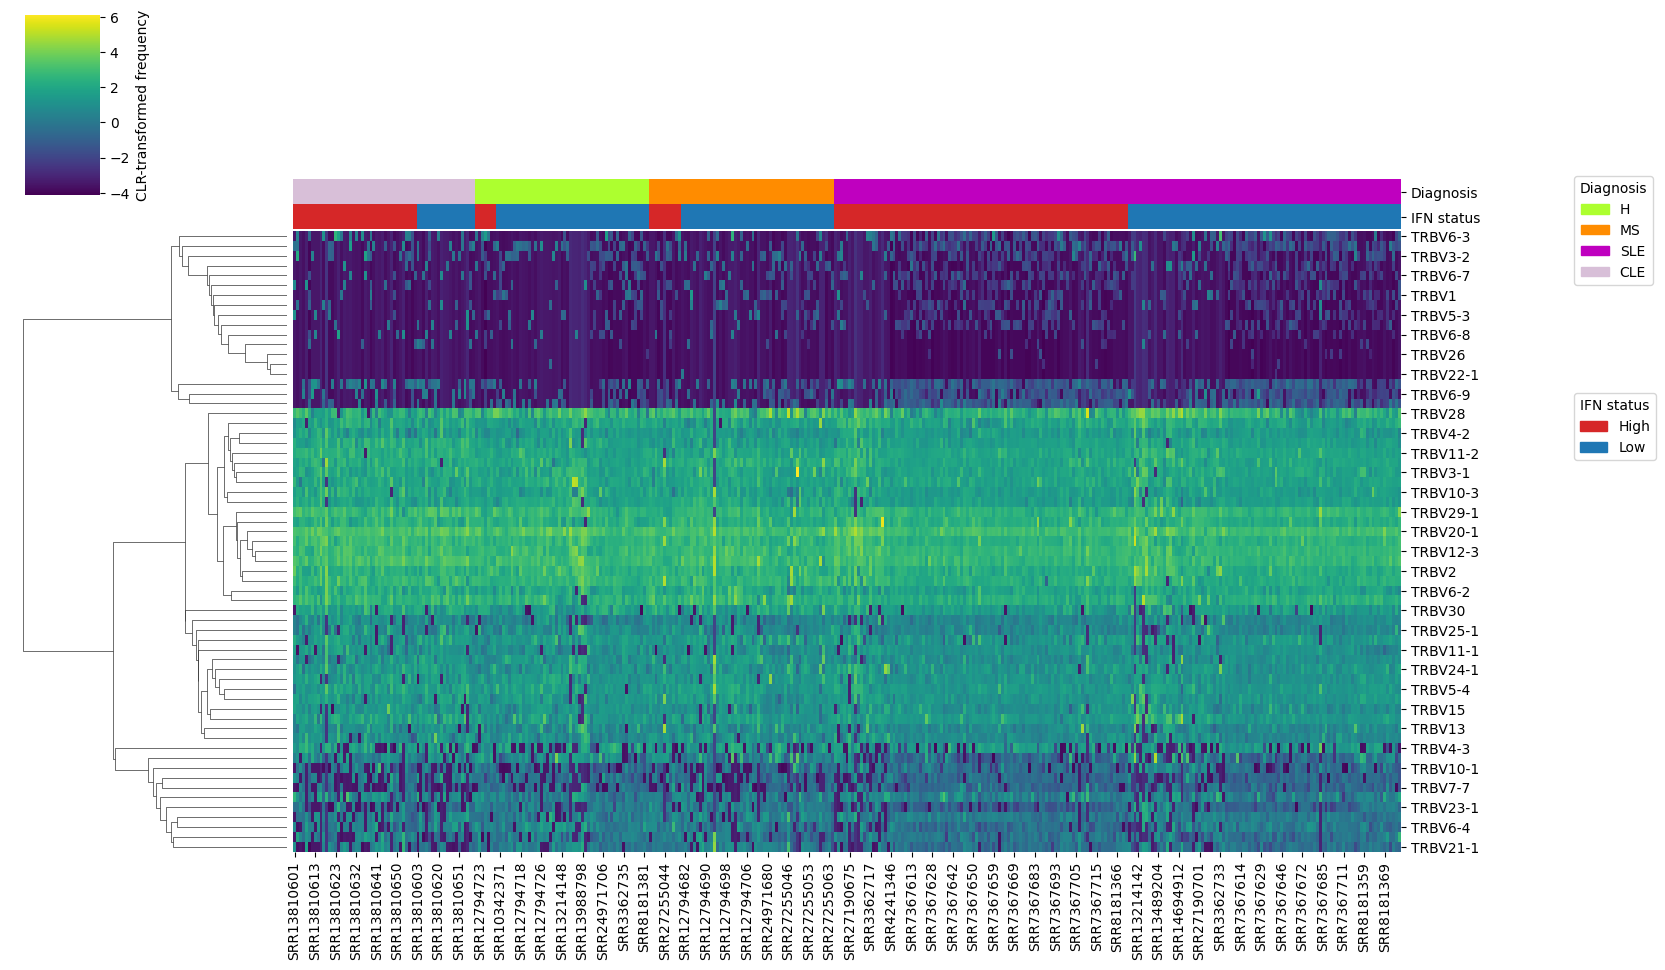

In [12]:
diagnosis_palette = {'H': 'greenyellow', 'MS': 'darkorange', 'SLE': 'm', 'CLE': 'thistle'}
ifn_palette = {"High": "#d62728", "Low": "#1f77b4"}

col_order = clr_V_df.sort_values(["diagnosis", "predicted_ifn_status"])["SRR"].values

col_colors = pd.DataFrame({
    "Diagnosis": clr_V_df.set_index("SRR").loc[col_order, "diagnosis"].map(diagnosis_palette),
    "IFN status": clr_V_df.set_index("SRR").loc[col_order, "predicted_ifn_status"].map(ifn_palette)
}, index=col_order)

data_matrix = clr_V_df.set_index("SRR")[v_gene_cols].T[col_order]

g = sns.clustermap(
    data=data_matrix,
    col_colors=col_colors,
    col_cluster=False,
    row_cluster=True,
    cmap="viridis",
    figsize=(15, 10),
    cbar_kws={"label": "CLR-transformed frequency"}
)

diag_patches = [mpatches.Patch(color=c, label=l) for l, c in diagnosis_palette.items()]
ifn_patches = [mpatches.Patch(color=c, label=l) for l, c in ifn_palette.items()]

leg1 = g.ax_heatmap.legend(
    handles=diag_patches, title="Diagnosis",
    loc="upper left", bbox_to_anchor=(1.15, 1.1),
    frameon=True
)
g.ax_heatmap.add_artist(leg1)

g.ax_heatmap.legend(
    handles=ifn_patches, title="IFN status",
    loc="upper left", bbox_to_anchor=(1.15, 0.75),
    frameon=True
)

g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")
plt.show()

For V-segment of TCR beta chained only 2 genes have shown higher frequencies for SLE samples with Low interferon beta response. This might imply their involvement in anti-interferon beta autoimmune response, but it should be noted that the effect size is small so these 2 changes are to be regarded as potential candidates with great caution. TRBV29-1 was not included in the analysis due to the highest p-value and the lowest size effect.

For multiple sclerosis and CLE no significantly presented V-genes were found in Low interferon response samples.

## D-segment gene usage

Only 2 TRBD genes are known to exist and participate in TCR formation. We used that as an opportunity to look closer into their frequency distributions. The initial pipeline for data preparation stays consistents with the V-gene usage analysis: generation of count matrix with subsequent frequencies calculation and CLR-transformation.


In [16]:
d_count_matrix = utils.get_gene_count_matrix("TRB", "D", results_path, metadata).T
d_gene_cols = d_count_matrix.columns
d_count_matrix.head()

gene,TRBD1,TRBD2
srr,,
SRR10342368,189.0,60.0
SRR10342369,1999.0,953.0
SRR10342370,1402.0,1104.0
SRR10342371,897.0,503.0
SRR12794681,291.0,211.0


In [17]:
d_freq_matrix = d_count_matrix.div(d_count_matrix.sum(axis=1), axis=0)
clr_d_matrix = utils.clr_transform(d_freq_matrix)
clr_d_df = clr_d_matrix.reset_index(names="SRR").merge(meta_subset, on = "SRR")
clr_d_df.head()


,SRR,TRBD1,TRBD2,diagnosis,Final_Batch,predicted_ifn_status,GSE
0,SRR10342368,0.573701,-0.573701,SLE,1,Low,GSE139350
1,SRR10342369,0.370394,-0.370394,SLE,1,Low,GSE139350
2,SRR10342370,0.119480,-0.119480,H,0,Low,GSE139350
3,SRR10342371,0.289233,-0.289233,H,1,Low,GSE139350
4,SRR12794681,0.160733,-0.160733,MS,2,Low,GSE159225


After generating all the needed tables we explored frequency distributions for both TRBD1 and TRBD2 genes for High and Low interferon response samples across different diagnosis groups. Distributions and mean values overlap completely for both interferon response groups in all diagnosis lables. Consequently, further analysis of the TRBD genes was discontinued, as the extensive overlap in distributions indicated a negligible probability of detecting statistically significant differences.

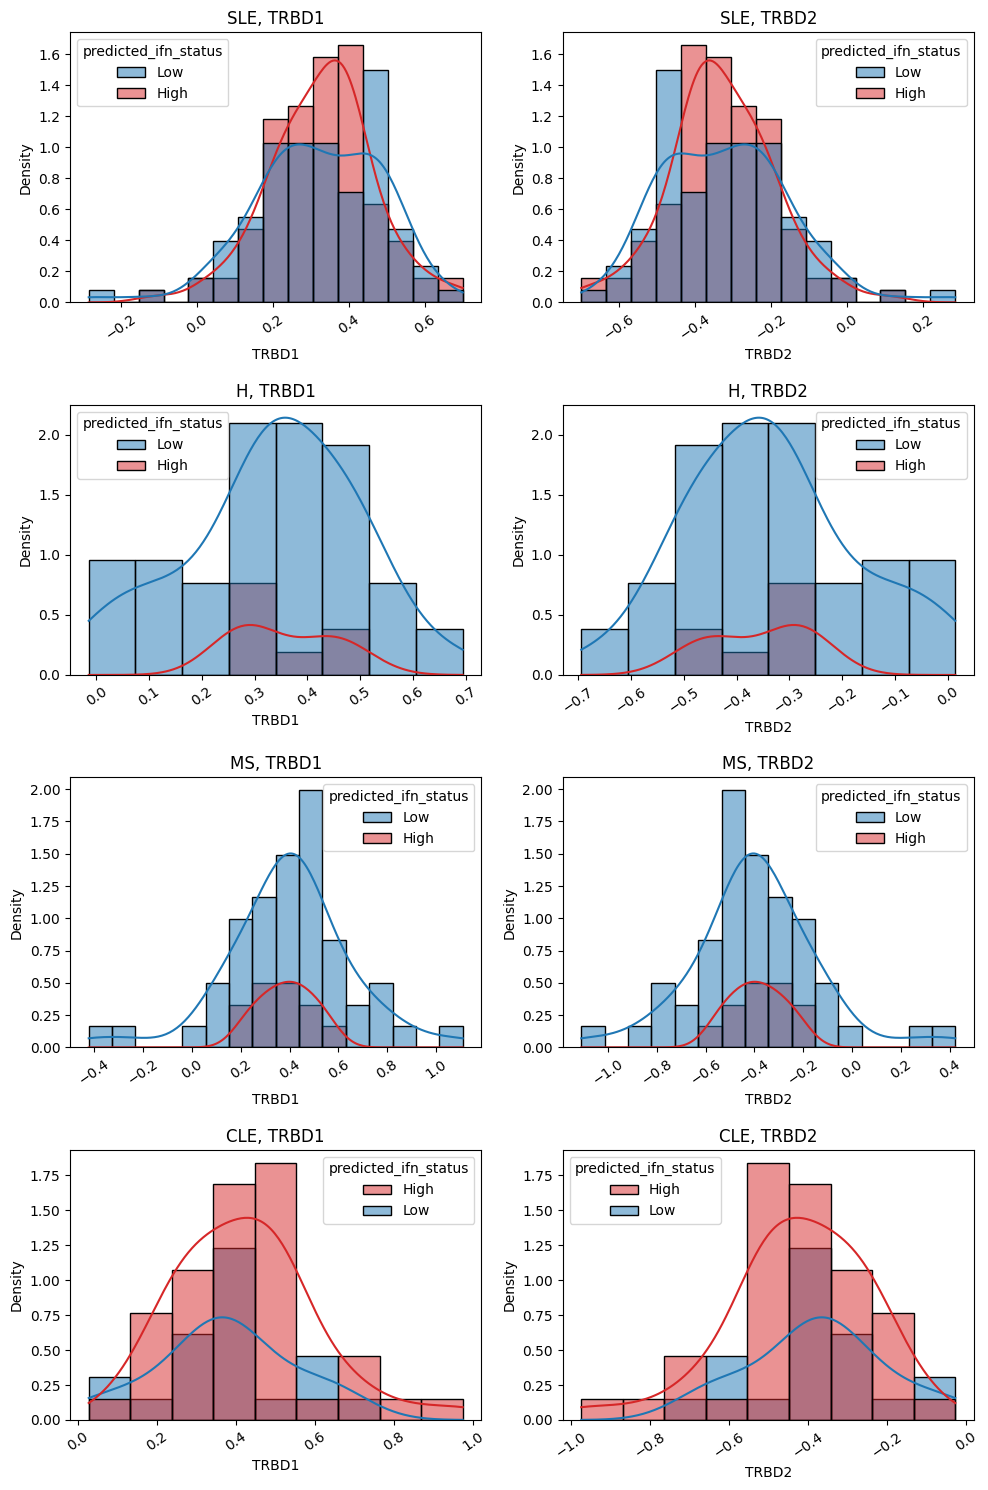

In [15]:
fig, axes = plt.subplots(4, 2, figsize=(10, 15))

for row, diagnosis in zip(axes, clr_d_df.diagnosis.unique()):
    for ax, d_gene in zip(row, d_gene_cols):
        sns.histplot(
            data=clr_d_df[clr_d_df.diagnosis == diagnosis], 
            x=d_gene,          
            kde=True,
            hue="predicted_ifn_status",
            ax=ax,
            stat="density",     
            palette = {'High': '#d62728', 'Low': '#1f77b4'}
        )
        ax.set_title(f"{diagnosis}, {d_gene}")
        ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

## J-segment gene usage

### Count and frequency matrix preparation

In [18]:
j_count_matrix = utils.get_gene_count_matrix("TRB", "J", results_path, metadata).T
j_freq_matrix = j_count_matrix.div(j_count_matrix.sum(axis=1), axis=0)
clr_j_matrix = utils.clr_transform(j_freq_matrix)

clr_j_df = clr_j_matrix.reset_index(names="SRR").merge(meta_subset, on="SRR", how="inner")
clr_j_df.head()

,SRR,TRBJ1-1,TRBJ1-2,TRBJ1-3,TRBJ1-4,TRBJ1-5,TRBJ1-6,TRBJ2-1,TRBJ2-2,TRBJ2-3,TRBJ2-4,TRBJ2-5,TRBJ2-6,TRBJ2-7,diagnosis,Final_Batch,predicted_ifn_status,GSE
0,SRR10342368,1.041824,0.693517,-0.405095,-1.791389,0.734339,-0.405095,1.689851,0.949451,1.126381,-5.187172,1.386664,-0.875099,1.041824,SLE,1,Low,GSE139350
1,SRR10342369,0.405573,-0.431824,-1.047584,-1.026531,-0.014930,-1.431996,2.473758,0.444602,0.643532,-0.528284,1.111081,-1.806689,1.209291,SLE,1,Low,GSE139350
2,SRR10342370,1.243258,0.260985,-1.596470,-1.308788,0.084427,-1.203427,1.770826,0.207560,0.592490,-1.021106,1.109108,-1.847784,1.708923,H,0,Low,GSE139350
3,SRR10342371,0.494110,0.126385,-1.524296,-1.424213,0.561703,-0.684545,1.466159,0.222613,0.883123,-1.067538,0.458519,-1.034748,1.522729,H,1,Low,GSE139350
4,SRR12794681,0.708234,0.240893,-1.306670,-0.613522,0.151946,-0.208057,1.296020,0.104317,0.856654,-1.529813,0.219387,-0.776041,0.856654,MS,2,Low,GSE159225
